In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
#loading
df=pd.read_csv("Mall_Customers.csv")
#showing the data
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [4]:
print("hello main branch !")

hello main branch !


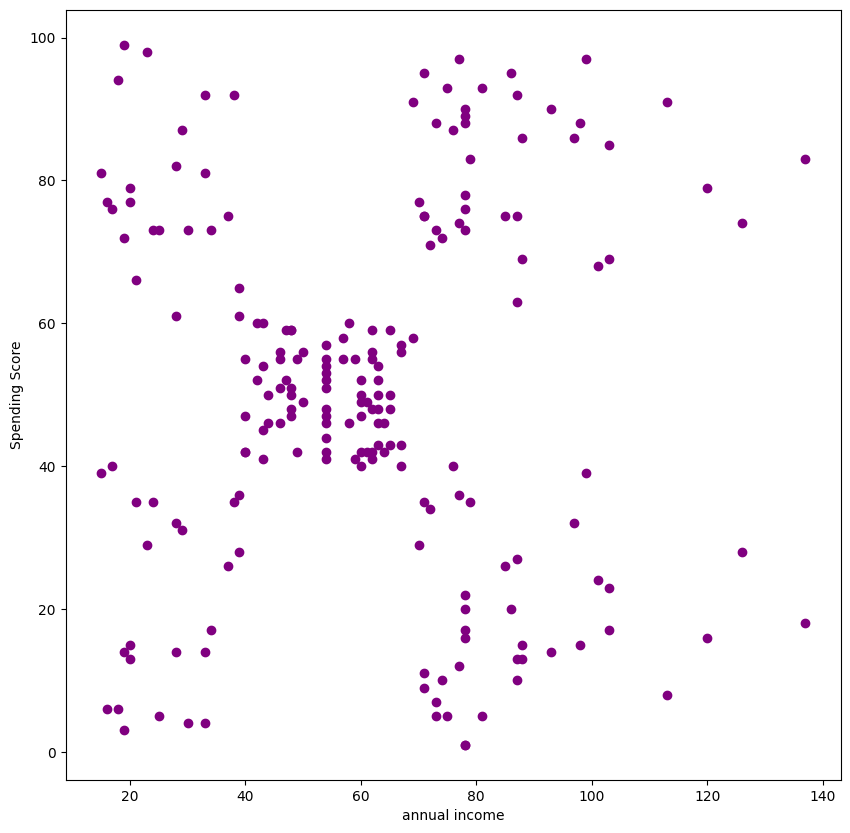

In [5]:
plt.figure(figsize=(10,10))
plt.scatter(df["Annual Income (k$)"],df["Spending Score (1-100)"],color="purple")
plt.xlabel("annual income")
plt.ylabel("Spending Score")
plt.show()

In [6]:
# yes i see possible groups in the scatter plot
# i see 5 possible groups
#to approximate the number of goups i tell my model to make 

In [7]:
df.drop(["CustomerID","Gender","Age"],axis=1, inplace=True)

In [8]:
#1 its is a noisy feature , does not help the clustring anyway
#2 because we are not trying to predict a class or a continious outcome, we are trying to group the poeple relying on their features 
#3 because we care more about the salary and the way of spending it , and if we add them , still having five groups, so not adding them is better for the prediction
#4 if we are gonna have more meaningful groups 

K = 1: Inertia = 269981.28
K = 2: Inertia = 181363.60
K = 3: Inertia = 106348.37
K = 4: Inertia = 73679.79
K = 5: Inertia = 44448.46
K = 6: Inertia = 37233.81
K = 7: Inertia = 30241.34
K = 8: Inertia = 25036.42
K = 9: Inertia = 21916.79
K = 10: Inertia = 20072.07


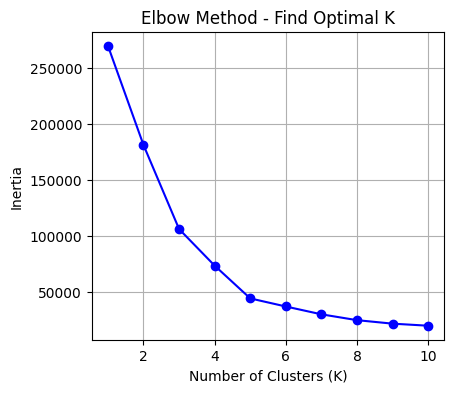

In [9]:
inertias = []  # Store inertia for each K

# Loop through different K values
for k in range(1,11):  # Try K=1 to 5
    # CREATE the model with current K
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    # TRAIN the model on our data
    kmeans.fit(df)
    
    # GET the inertia (how compact clusters are)
    inertias.append(kmeans.inertia_)
    
    print(f"K = {k}: Inertia = {kmeans.inertia_:.2f}")

# Plot elbow curve
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1,11), inertias, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method - Find Optimal K')
plt.grid(True)

In [10]:
#1 inirtia is the includian distance between each point(row) to the centeroid of its group  foreach group
#2 i see that the best one is 5 , cuz when we look at the gragh , we see that after five , the distance between Ks are stable (the same)
#so there is a slight diffrence in inirtia after 5 
#3 if the k was too small , we are gonna have a group for only few points (too many groups) where we can have less groups with same efficent
#4 if the k was so large , we are gonna ignore the borders btween totaly diffrent groups what makes our model predictions so poor (it generlizes in bad way)

In [11]:
k = 5
model = KMeans(n_clusters=k, random_state=42, n_init=10)

clusters = model.fit_predict(df)
# GET the cluster labels
df['Cluster'] =clusters
# EXTRACT CENTROIDS 
centroids = model.cluster_centers_
print(centroids)


[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


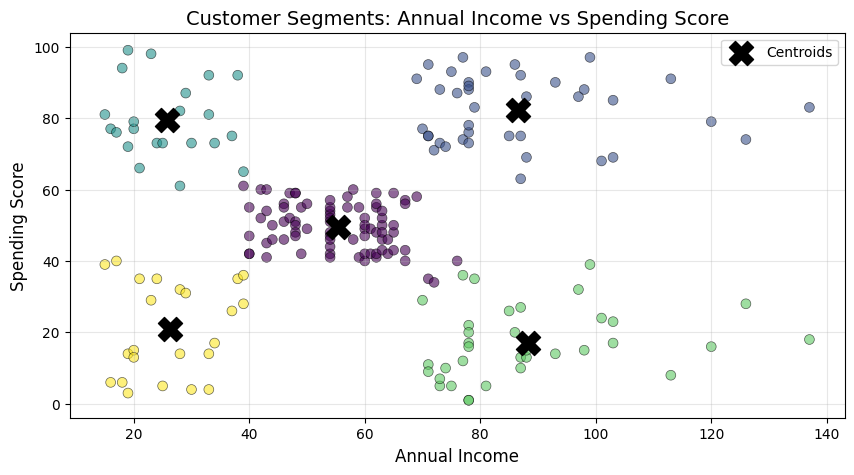

In [12]:

plt.figure(figsize=(10, 5))


plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c=clusters, cmap='viridis', 
                      s=50, alpha=0.6, edgecolors='black', linewidth=0.5)


plt.scatter(centroids[:, 0], centroids[:, 1], 
            marker='X', s=300, c='black', edgecolors='black',
            linewidth=1, label='Centroids', zorder=5)

plt.title('Customer Segments: Annual Income vs Spending Score', fontsize=14)
plt.xlabel('Annual Income', fontsize=12)
plt.ylabel('Spending Score', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
